# Breast Cancer Prediction Project

Welcome to the Breast Cancer Prediction project! 🎯

In this beginner-friendly notebook, we'll walk through a step-by-step machine learning pipeline to predict whether a tumor is malignant or benign based on various features.

## 🔍 Objective

Our goal is to build a machine learning model that can accurately predict whether a tumor is **malignant (M)** or **benign (B)** based on a set of measurements.

We'll use the dataset `Cancer_Data.csv` for this purpose.

In [1]:
# 📦 Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📥 Step 1: Load the Dataset

In [ ]:
# Load the dataset
df = pd.read_csv(Cancer_Data.csv')

print(f'✅ Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded successfully!
Shape: 569 rows × 33 columns


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 🔍 Step 2: Explore the Dataset

In [5]:
# Basic info
print('📋 Dataset Info:')
print('-' * 40)
df.info()

📋 Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se             

In [6]:
# Statistical summary
print('📊 Statistical Summary:')
df.describe().T.style.background_gradient(cmap='Blues')

📊 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
id,569.000000,30371831.432337,125020585.612224,8670.000000,869218.000000,906024.000000,8813129.000000,911320502.000000
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000


In [7]:
# Check class distribution
print('🔢 Diagnosis Distribution:')
print(df['diagnosis'].value_counts())
print(f"\nMalignant (M): {(df['diagnosis']=='M').sum()} ({(df['diagnosis']=='M').mean()*100:.1f}%)")
print(f"Benign    (B): {(df['diagnosis']=='B').sum()} ({(df['diagnosis']=='B').mean()*100:.1f}%)")

🔢 Diagnosis Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Malignant (M): 212 (37.3%)
Benign    (B): 357 (62.7%)


In [8]:
# Check missing values
print('🕵️ Missing Values per Column:')
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) == 0:
    print('✅ No missing values found (except possibly Unnamed: 32)')
else:
    print(missing_cols)

🕵️ Missing Values per Column:
Unnamed: 32    569
dtype: int64


## 🧹 Step 3: Clean the Data

#### We'll remove any unnecessary columns and handle missing values.

In [9]:
# Drop 'Unnamed: 32' (all NaN) and 'id' (not a feature)
cols_to_drop = [col for col in ['Unnamed: 32', 'id'] if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

# Drop any rows with remaining NaN values (safety check)
df.dropna(inplace=True)

print(f'✅ Cleaned! Dropped columns: {cols_to_drop}')
print(f'📐 New shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Cleaned! Dropped columns: ['Unnamed: 32', 'id']
📐 New shape: 569 rows × 31 columns


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 📊 Step 4: Visualize the Data

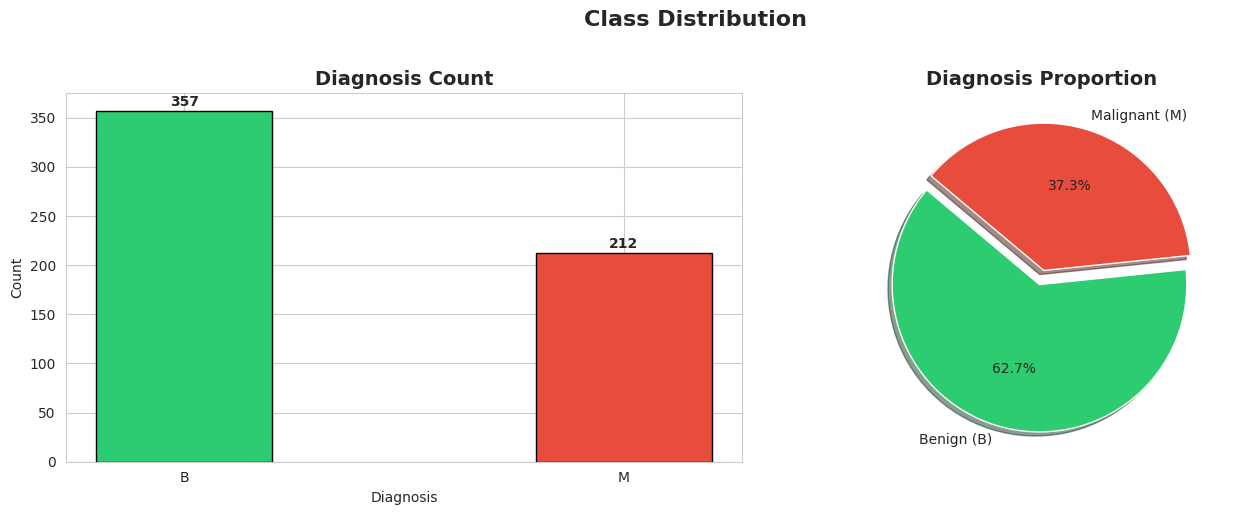

In [10]:
# ── 4.1 Class Distribution Pie + Bar ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['diagnosis'].value_counts()
colors = ['#2ecc71', '#e74c3c']

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.4)
axes[0].set_title('Diagnosis Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Benign (B)', 'Malignant (M)'],
            colors=colors, autopct='%1.1f%%', startangle=140,
            explode=(0.05, 0.05), shadow=True)
axes[1].set_title('Diagnosis Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

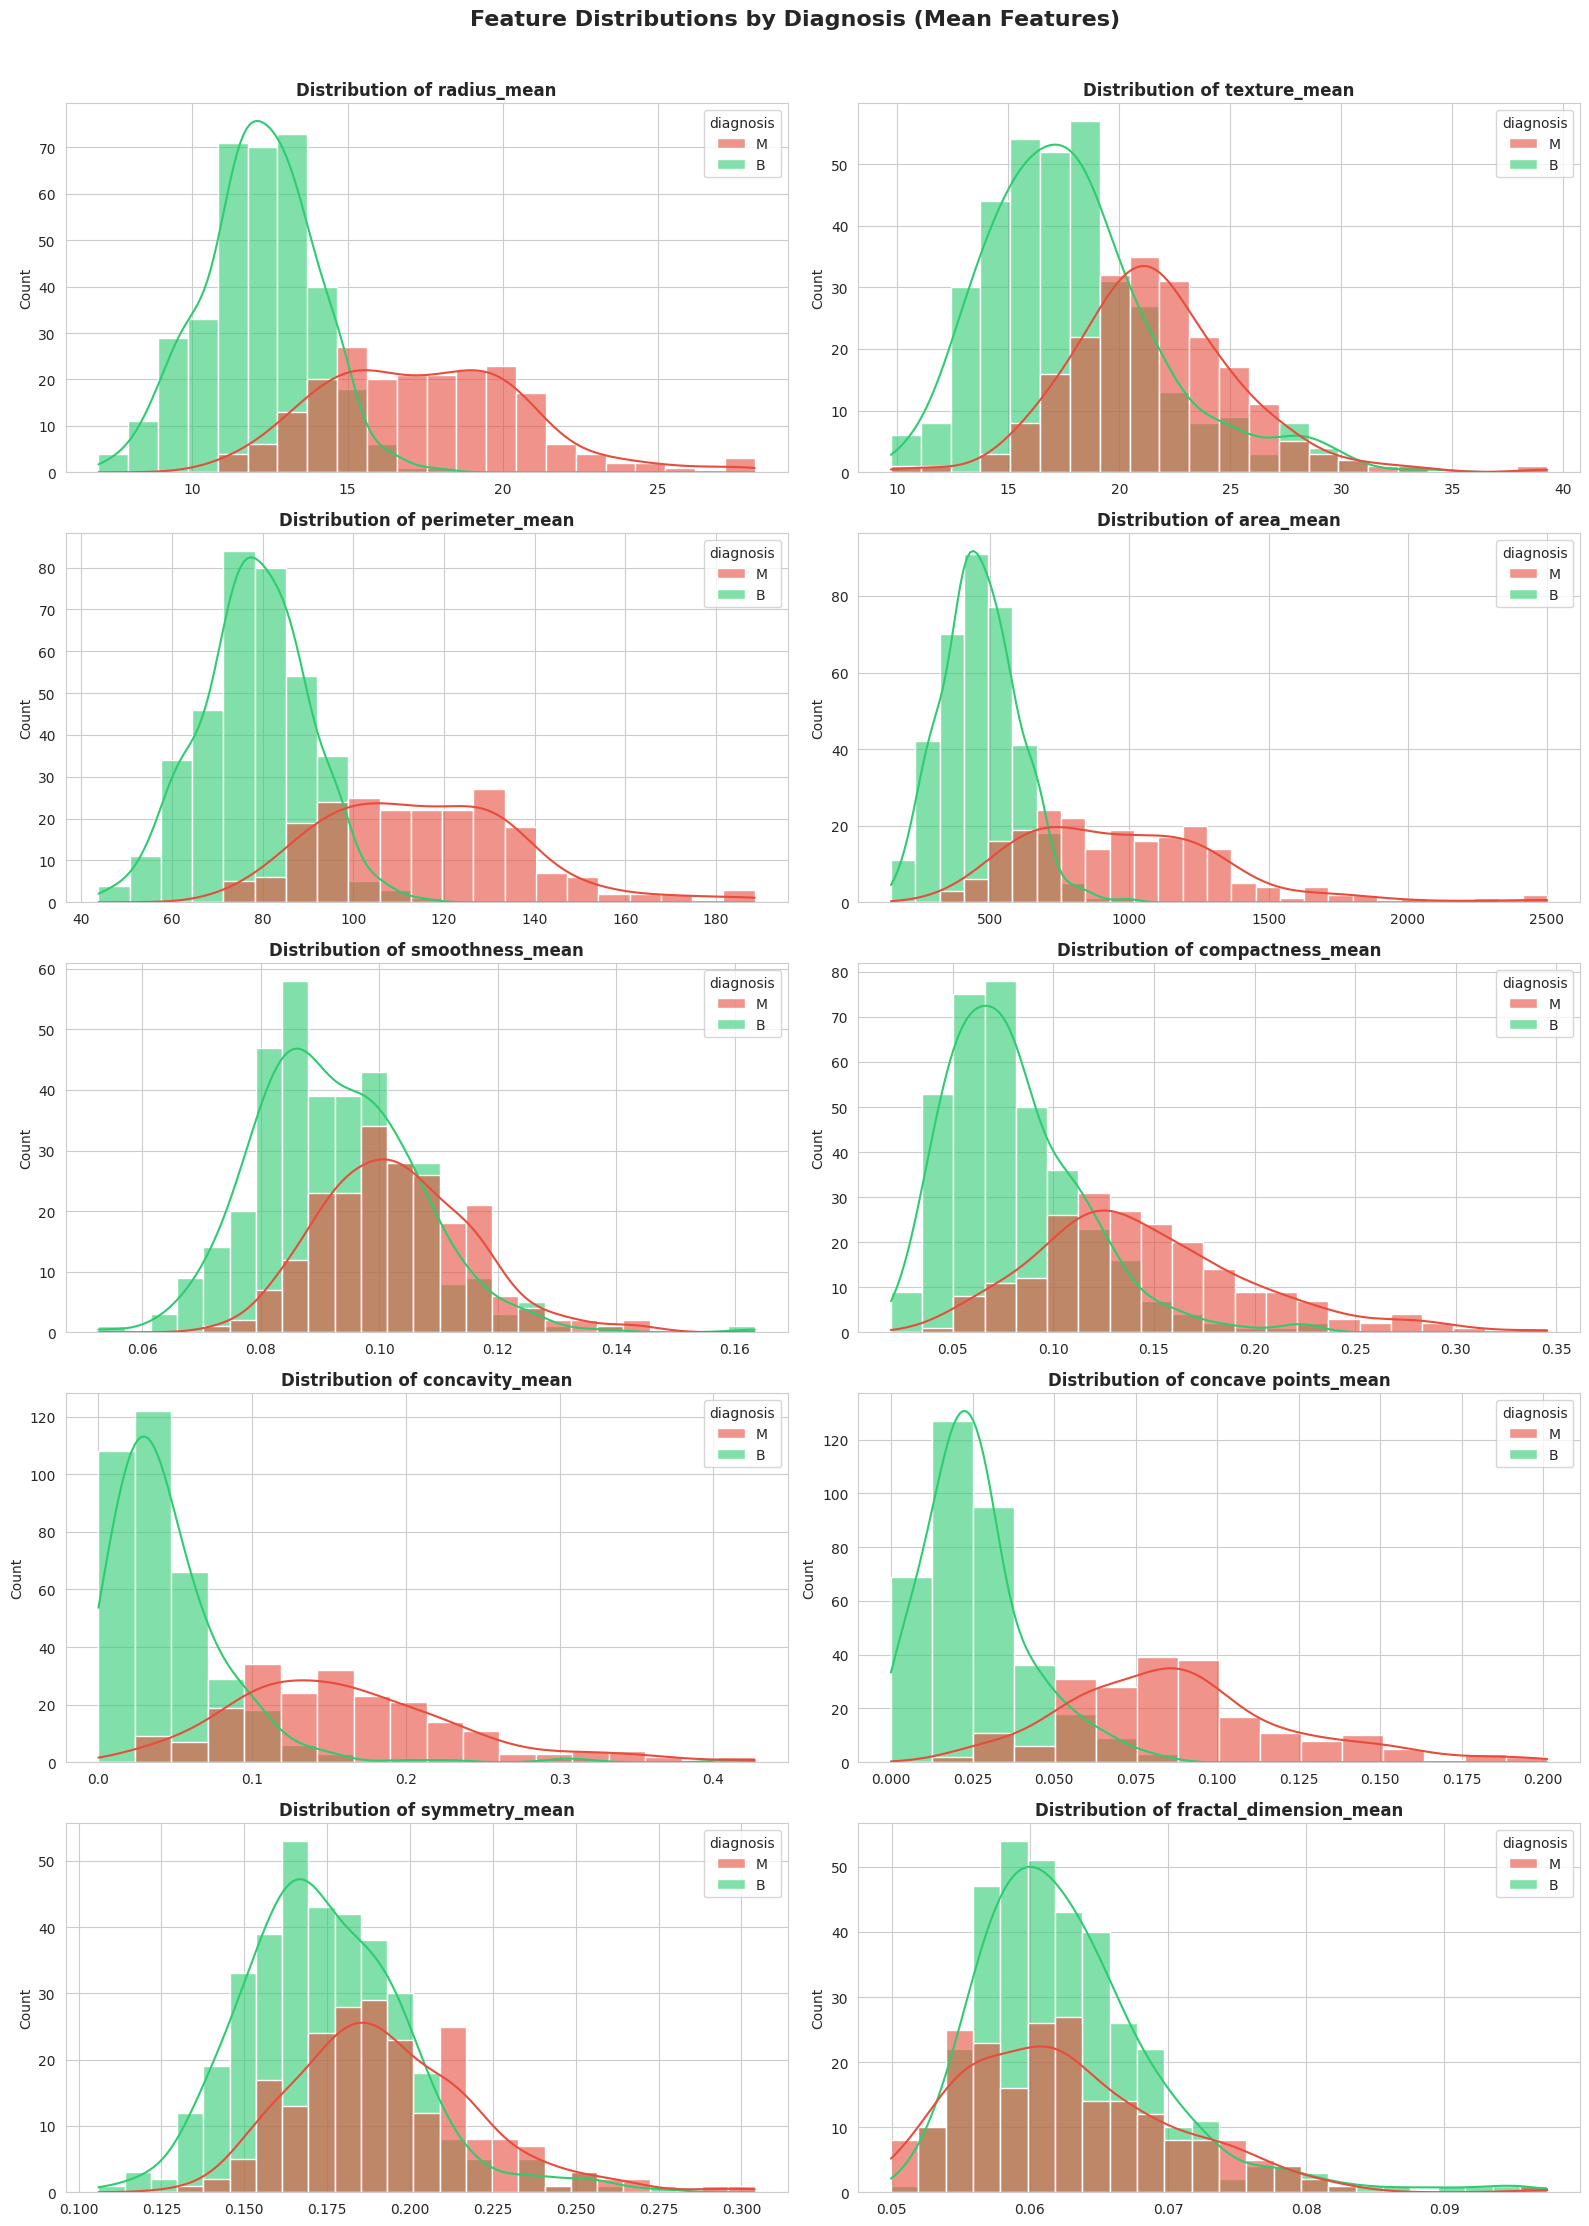

In [11]:
# ── 4.2 Feature Distributions: Mean Features by Diagnosis ──
mean_features = [c for c in df.columns if c.endswith('_mean')]

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

for i, feat in enumerate(mean_features):
    sns.histplot(data=df, x=feat, hue='diagnosis', kde=True,
                 palette={'M': '#e74c3c', 'B': '#2ecc71'},
                 ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Distribution of {feat}', fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Diagnosis (Mean Features)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

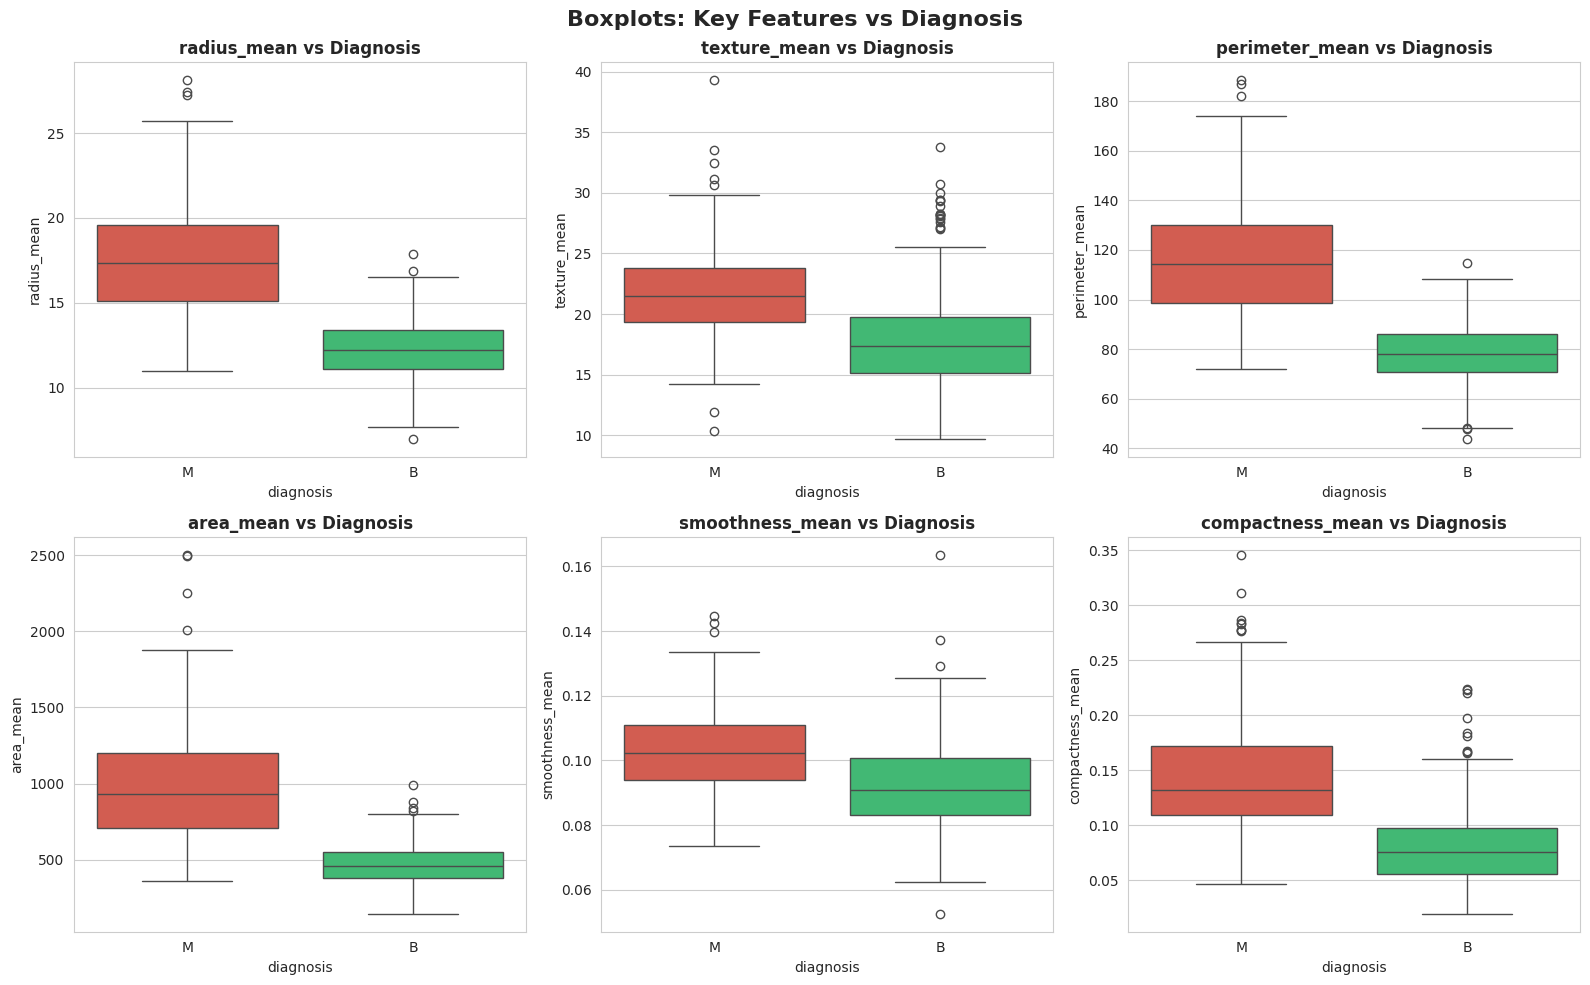

In [12]:
# ── 4.3 Boxplots: Key Features vs Diagnosis ──
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean',
                'area_mean', 'smoothness_mean', 'compactness_mean']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x='diagnosis', y=feat,
                palette={'M': '#e74c3c', 'B': '#2ecc71'}, ax=axes[i])
    axes[i].set_title(f'{feat} vs Diagnosis', fontweight='bold')

plt.suptitle('Boxplots: Key Features vs Diagnosis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

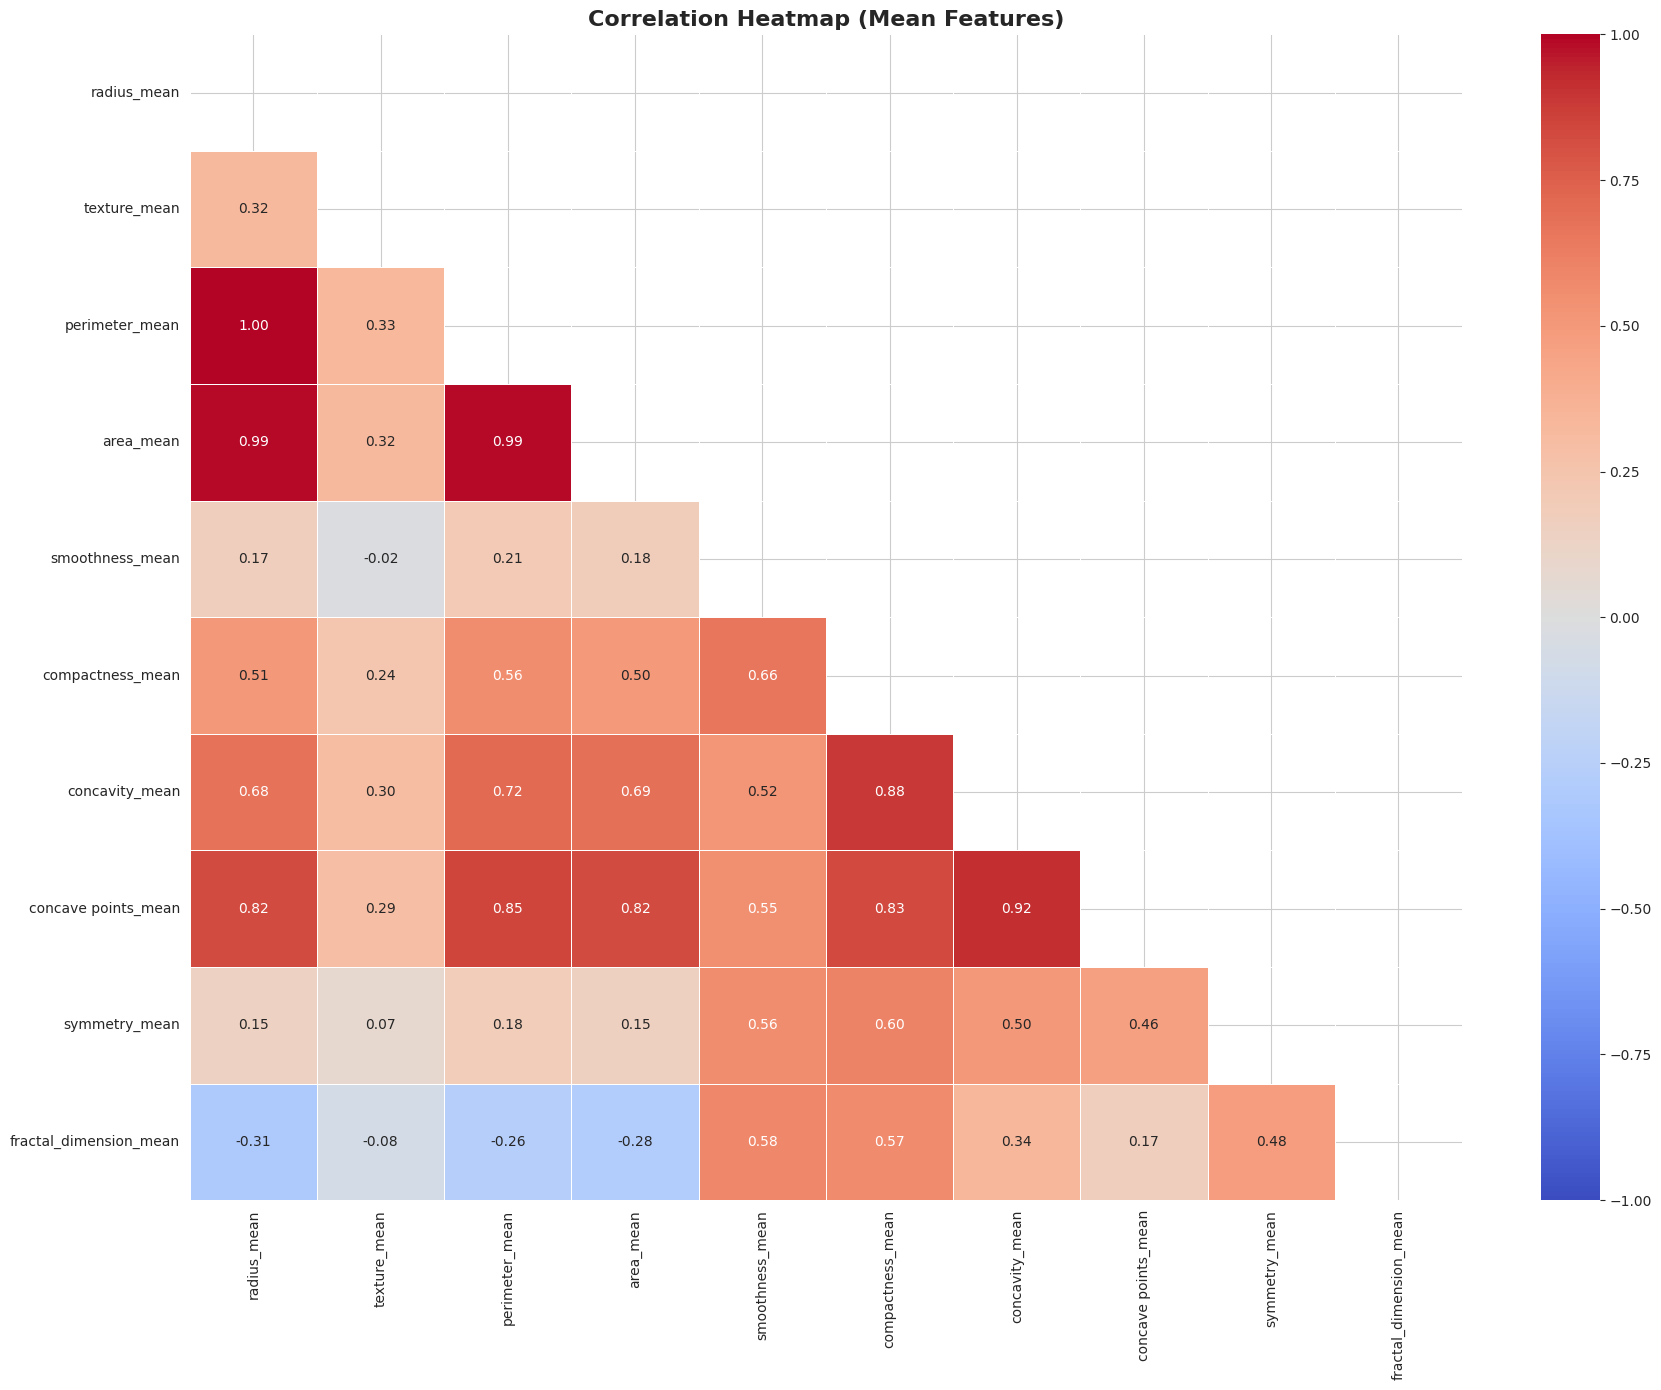

In [13]:
# ── 4.4 Correlation Heatmap ──
plt.figure(figsize=(18, 14))
corr = df[mean_features].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap (Mean Features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

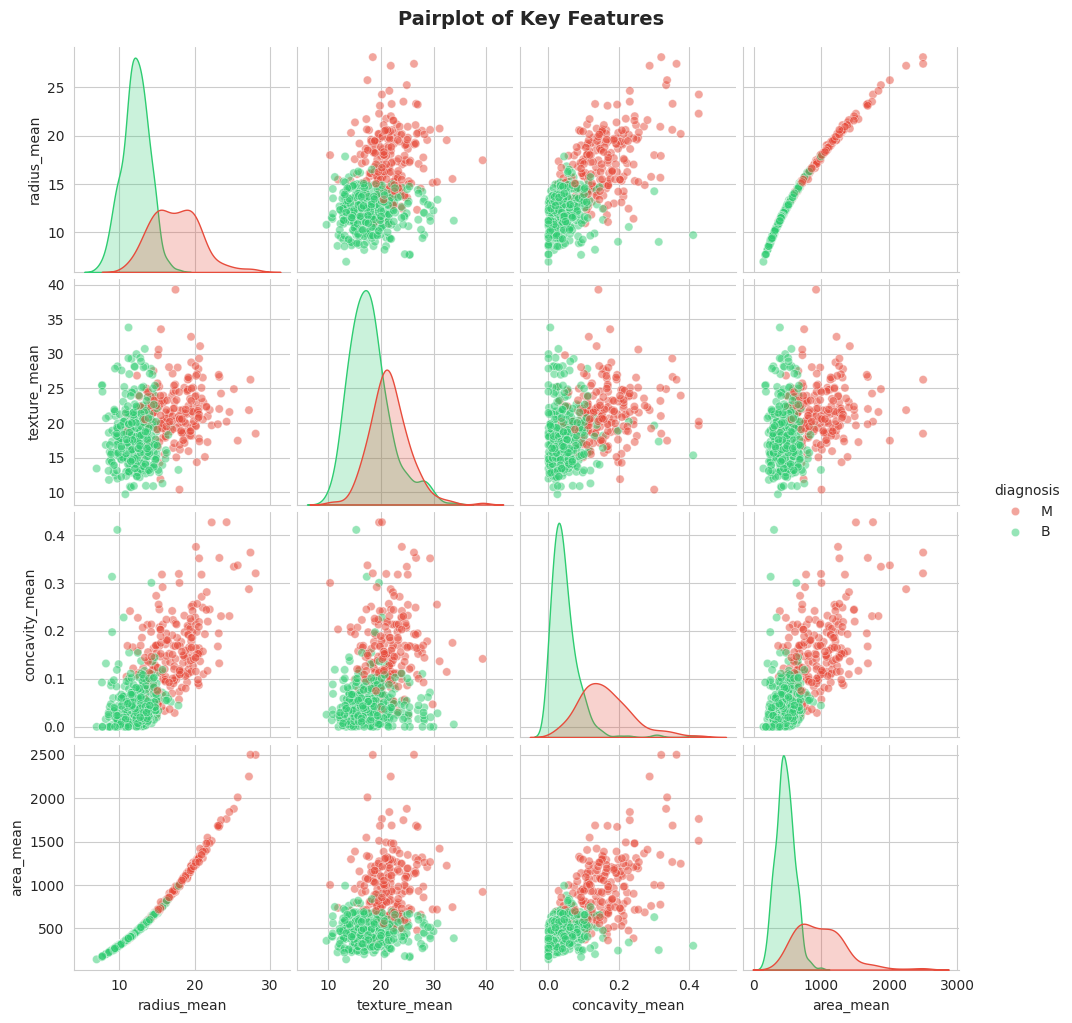

In [14]:
# ── 4.5 Pairplot: Top 4 Discriminating Features ──
top_features = ['radius_mean', 'texture_mean', 'concavity_mean', 'area_mean', 'diagnosis']
sns.pairplot(df[top_features], hue='diagnosis',
             palette={'M': '#e74c3c', 'B': '#2ecc71'},
             diag_kind='kde', plot_kws={'alpha': 0.5})

plt.suptitle('Pairplot of Key Features', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## ⚙️ Step 5: Preprocess the Data

In [15]:
# Convert diagnosis: M → 1 (Malignant), B → 0 (Benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print('✅ Encoded: Malignant=1, Benign=0')
print(df['diagnosis'].value_counts())

# Split features (X) and label (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print(f'\n📐 Features shape : {X.shape}')
print(f'📐 Labels shape   : {y.shape}')

✅ Encoded: Malignant=1, Benign=0
diagnosis
0    357
1    212
Name: count, dtype: int64

📐 Features shape : (569, 30)
📐 Labels shape   : (569,)


In [16]:
# Train / Test split — 80% train, 20% test, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'✅ Train set : {X_train.shape[0]} samples')
print(f'✅ Test set  : {X_test.shape[0]} samples')

✅ Train set : 455 samples
✅ Test set  : 114 samples


In [17]:
# Feature Scaling with StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # transform test

print('✅ Features scaled using StandardScaler')
print(f'Mean of first feature (train): {X_train_scaled[:, 0].mean():.4f}  (≈ 0)')
print(f'Std  of first feature (train): {X_train_scaled[:, 0].std():.4f}  (≈ 1)')

✅ Features scaled using StandardScaler
Mean of first feature (train): -0.0000  (≈ 0)
Std  of first feature (train): 1.0000  (≈ 1)


---
## 🤖 Step 6: Train a Machine Learning Model

We'll train **three models**: Logistic Regression, Random Forest, and SVM.

In [18]:
# ── 6.1 Logistic Regression ──
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
print('✅ Logistic Regression trained!')

✅ Logistic Regression trained!


In [19]:
# ── 6.2 Random Forest ──
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
print('✅ Random Forest trained!')

✅ Random Forest trained!


In [20]:
# ── 6.3 Support Vector Machine ──
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
print('✅ SVM trained!')

✅ SVM trained!


## 🧪 Step 7: Evaluate the Model

In [21]:
# Helper function to evaluate any model
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc    = accuracy_score(y_test, y_pred)
    roc    = roc_auc_score(y_test, y_prob)

    print(f'\n{"="*50}')
    print(f'  📌 {model_name}')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'  ROC-AUC  : {roc:.4f}')
    print(f'{"-"*50}')
    print(classification_report(y_test, y_pred,
                                 target_names=['Benign (0)', 'Malignant (1)']))
    return y_pred, y_prob, acc, roc


lr_pred,  lr_prob,  lr_acc,  lr_roc  = evaluate_model(lr_model,  X_test_scaled, y_test, 'Logistic Regression')
rf_pred,  rf_prob,  rf_acc,  rf_roc  = evaluate_model(rf_model,  X_test_scaled, y_test, 'Random Forest')
svm_pred, svm_prob, svm_acc, svm_roc = evaluate_model(svm_model, X_test_scaled, y_test, 'Support Vector Machine')


  📌 Logistic Regression
  Accuracy : 96.49%
  ROC-AUC  : 0.9960
--------------------------------------------------
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114


  📌 Random Forest
  Accuracy : 97.37%
  ROC-AUC  : 0.9929
--------------------------------------------------
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114


  📌 Support Vector Machine
  Accuracy : 97.37%
  ROC-AUC  : 0.9947
----------------------------------------

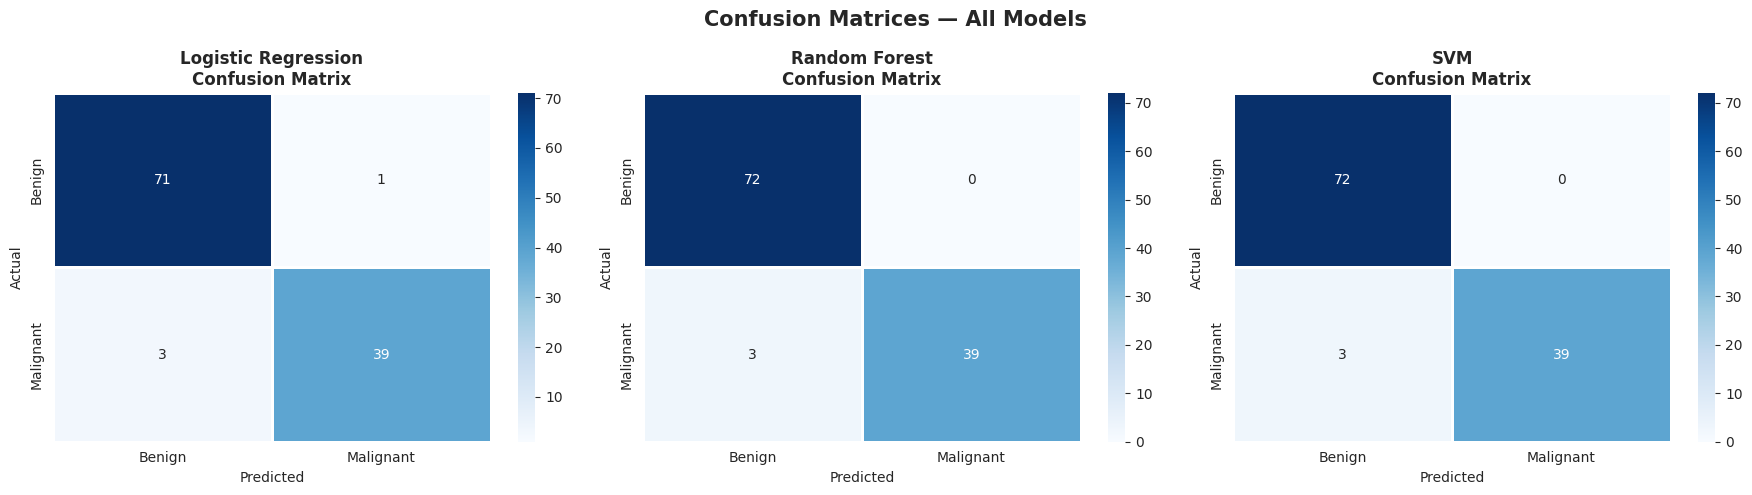

In [22]:
# ── 7.1 Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    (lr_pred,  'Logistic Regression', '#3498db'),
    (rf_pred,  'Random Forest',       '#2ecc71'),
    (svm_pred, 'SVM',                 '#9b59b6'),
]

for ax, (pred, name, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'],
                linewidths=1)
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

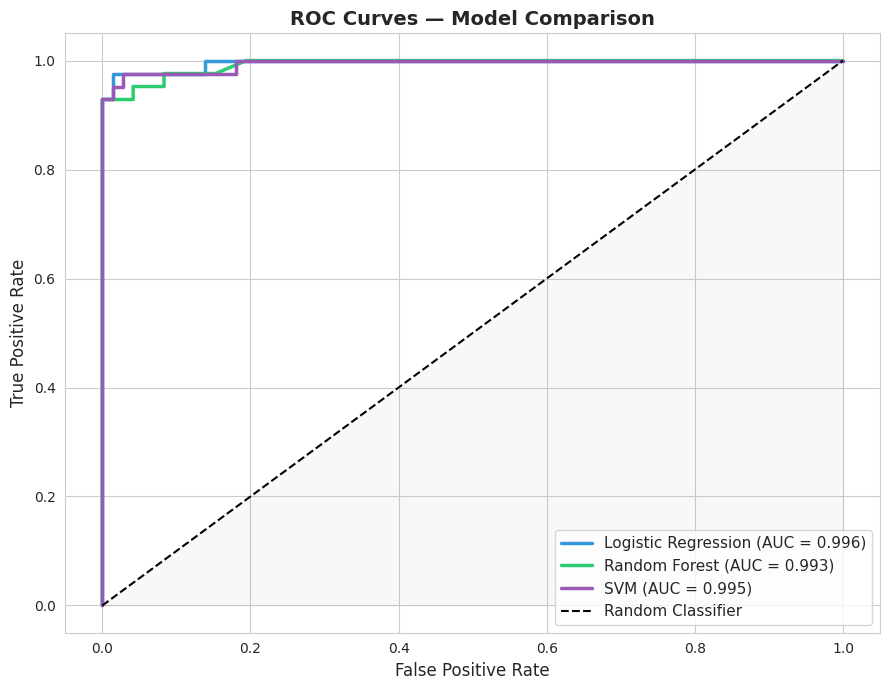

In [23]:
# ── 7.2 ROC Curves ──
plt.figure(figsize=(9, 7))

for prob, name, color, roc in [
    (lr_prob,  'Logistic Regression', '#3498db', lr_roc),
    (rf_prob,  'Random Forest',       '#2ecc71', rf_roc),
    (svm_prob, 'SVM',                 '#9b59b6', svm_roc),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc:.3f})', color=color, lw=2.5)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

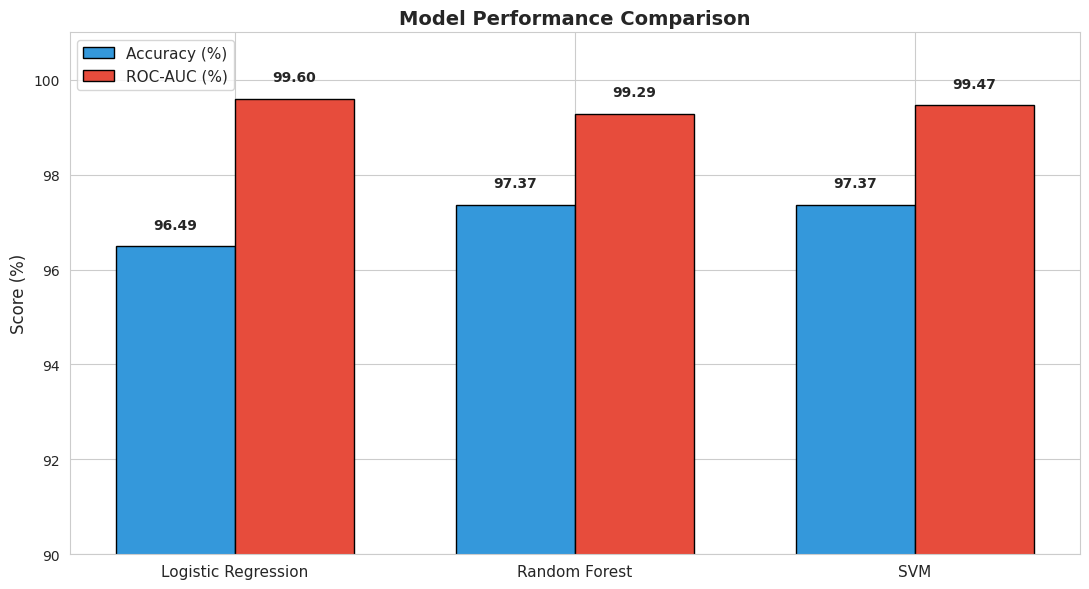

In [24]:
# ── 7.3 Model Comparison Bar Chart ──
model_names  = ['Logistic Regression', 'Random Forest', 'SVM']
accuracies   = [lr_acc, rf_acc, svm_acc]
roc_aucs     = [lr_roc, rf_roc, svm_roc]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, [a*100 for a in accuracies], width,
               label='Accuracy (%)', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, [r*100 for r in roc_aucs], width,
               label='ROC-AUC (%)', color='#e74c3c', edgecolor='black')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(90, 101)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

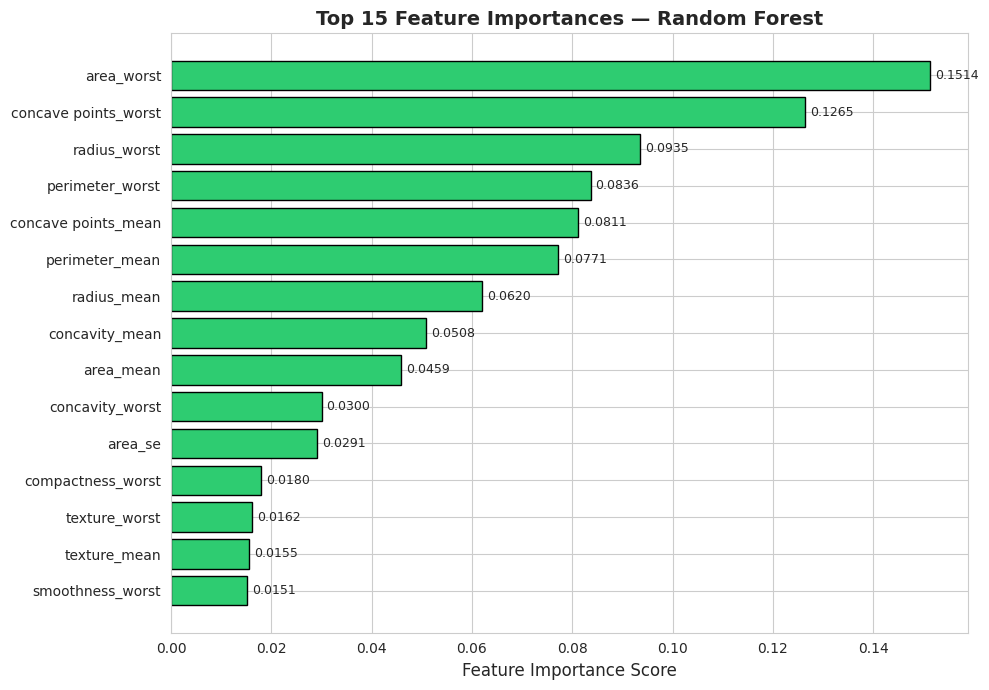

In [25]:
# ── 7.4 Feature Importance (Random Forest) ──
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(10, 7))
bars = plt.barh(top_15.index, top_15.values, color='#2ecc71', edgecolor='black')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_15.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 🔧 Step 8: Feature Selection

We'll use the top features from Random Forest to see if a smaller model performs comparably.

In [26]:
# Select top 10 features
top10_features = importances.nlargest(10).index.tolist()
print('🏆 Top 10 Features:', top10_features)

X_train_top = scaler.fit_transform(X_train[top10_features])
X_test_top  = scaler.transform(X_test[top10_features])

# Retrain Logistic Regression on top 10 features
lr_top = LogisticRegression(max_iter=1000, random_state=42)
lr_top.fit(X_train_top, y_train)
top_pred = lr_top.predict(X_test_top)

print(f'\n📊 LR with Top 10 Features  Accuracy: {accuracy_score(y_test, top_pred)*100:.2f}%')
print(f'📊 LR with All Features     Accuracy: {lr_acc*100:.2f}%')

🏆 Top 10 Features: ['area_worst', 'concave points_worst', 'radius_worst', 'perimeter_worst', 'concave points_mean', 'perimeter_mean', 'radius_mean', 'concavity_mean', 'area_mean', 'concavity_worst']

📊 LR with Top 10 Features  Accuracy: 95.61%
📊 LR with All Features     Accuracy: 96.49%


---
## 🔩 Step 9: Hyperparameter Tuning (Logistic Regression)

Use `GridSearchCV` to find the best `C` and `solver` for Logistic Regression.

In [27]:
# Grid Search on Logistic Regression
param_grid = {
    'C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'solver':  ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print(f'✅ Best Parameters : {grid_search.best_params_}')
print(f'✅ Best CV Accuracy: {grid_search.best_score_*100:.2f}%')

best_lr = grid_search.best_estimator_
best_pred = best_lr.predict(X_test_scaled)
print(f'✅ Test  Accuracy  : {accuracy_score(y_test, best_pred)*100:.2f}%')

✅ Best Parameters : {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
✅ Best CV Accuracy: 97.36%
✅ Test  Accuracy  : 98.25%


In [28]:
# ── Cross-Validation scores for all models ──
print('📊 5-Fold Cross-Validation Accuracy:')
print('-' * 45)
for model, name in [
    (lr_model,  'Logistic Regression (default)'),
    (best_lr,   'Logistic Regression (tuned) '),
    (rf_model,  'Random Forest               '),
    (svm_model, 'SVM                         '),
]:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    print(f'{name}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%')

📊 5-Fold Cross-Validation Accuracy:
---------------------------------------------
Logistic Regression (default): 97.14% ± 1.12%
Logistic Regression (tuned) : 97.36% ± 1.79%
Random Forest               : 96.26% ± 3.38%
SVM                         : 97.58% ± 1.28%


## ✅ Conclusion

Awesome work! 🎉

You've successfully built a breast cancer prediction model using Logistic Regression. You explored the data, cleaned it, visualized it, trained a model, and evaluated its performance.

### 🚀 Next Steps
- Try different models like RandomForest or SVM
- Perform feature selection
- Tune hyperparameters for better accuracy

In [29]:
# Final summary table
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Logistic Regression (Tuned)', 'Random Forest', 'SVM'],
    'Test Accuracy (%)': [
        round(lr_acc * 100, 2),
        round(accuracy_score(y_test, best_pred) * 100, 2),
        round(rf_acc * 100, 2),
        round(svm_acc * 100, 2)
    ],
    'ROC-AUC': [
        round(lr_roc, 4),
        round(roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:, 1]), 4),
        round(rf_roc, 4),
        round(svm_roc, 4)
    ]
})

summary = summary.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)
summary.index += 1
summary.style.background_gradient(subset=['Test Accuracy (%)', 'ROC-AUC'], cmap='Greens')

,Model,Test Accuracy (%),ROC-AUC
1,Logistic Regression (Tuned),98.250000,0.997700
2,Random Forest,97.370000,0.992900
3,SVM,97.370000,0.994700
4,Logistic Regression,96.490000,0.996000
